# Intro to Computer Vision
Welcome to the interactive portion! In the next 30 minutes, we are going to teach your computer how to see.

**Our Agenda:**
1. Color Segmentation (HSV Thresholding)
2. Object Detection (YOLOv8)

Let's start by importing our essential libraries.

In [7]:
# Install YOLO (Ultralytics makes this incredibly easy)
!pip install ultralytics -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from sklearn.mixture import GaussianMixture
from ultralytics import YOLO

In [8]:
# Helper function to download images directly from the web to our Colab
def url_to_image(url):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    resp = urllib.request.urlopen(req)

    image = np.asarray(bytearray(resp.read()), dtype="uint8")
    image = cv2.imdecode(image, cv2.IMREAD_COLOR)
    return image

print("Libraries imported successfully!")

Libraries imported successfully!


## Part 1: Color Segmentation (The "Green Screen" Effect)
RGB (Red, Green, Blue) is great for monitors, but terrible for computer vision. If a shadow falls on a red apple, its R, G, and B values *all* change.

To track color reliably, we convert the image to **HSV (Hue, Saturation, Value)**. "Hue" represents the pure color, independent of lighting.

Let's isolate all the blue objects in an image!

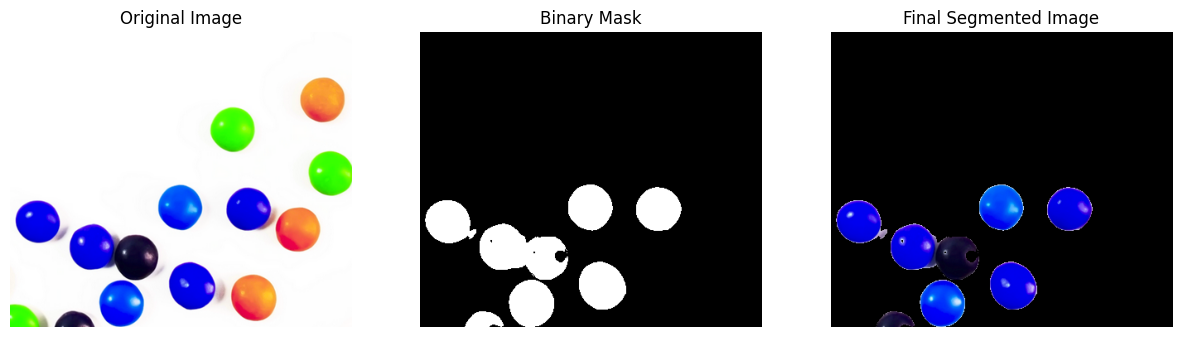

In [10]:
# Load an image of colorful smarties
img_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/smarties.png"
image = url_to_image(img_url)

# Convert from RGB to HSV
hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# Define the strict boundaries for the color BLUE in HSV space
# OpenCV hue range is 0-180 (half of 0-360).
# Blue in real degrees is ~180-280°, so in OpenCV that's 90-140.
# S and V are kept wide (low minimums) to catch pale and dark blues too.
lower_blue = np.array([90, 30, 20])
upper_blue = np.array([140, 255, 255])

# Create a binary mask (Pixels in range = White/1, outside = Black/0)
mask = cv2.inRange(hsv_image, lower_blue, upper_blue)

kernel = np.ones((5, 5), np.uint8)

# Apply the mask to the original image using a bitwise AND
result = cv2.bitwise_and(image, image, mask=mask)

# Show final image
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(image); axs[0].set_title("Original Image")
axs[1].imshow(mask, cmap='gray'); axs[1].set_title("Binary Mask")
axs[2].imshow(result); axs[2].set_title("Final Segmented Image")
for ax in axs: ax.axis('off')
plt.show()

## Part 3: Custom Convolutions (The Sliding Window)
Before we use YOLO, let's actually build the "eyes" of a neural network from scratch.

We are going to define a 3x3 matrix (called a **kernel**) and slide it across an image. By changing the numbers in this tiny 3x3 grid, we can magically extract edges, sharpen the image, or blur it out. This exact math is the foundational building block of all modern AI vision models!

Play around with the numbers in the `custom_kernel` matrix and see what happens.

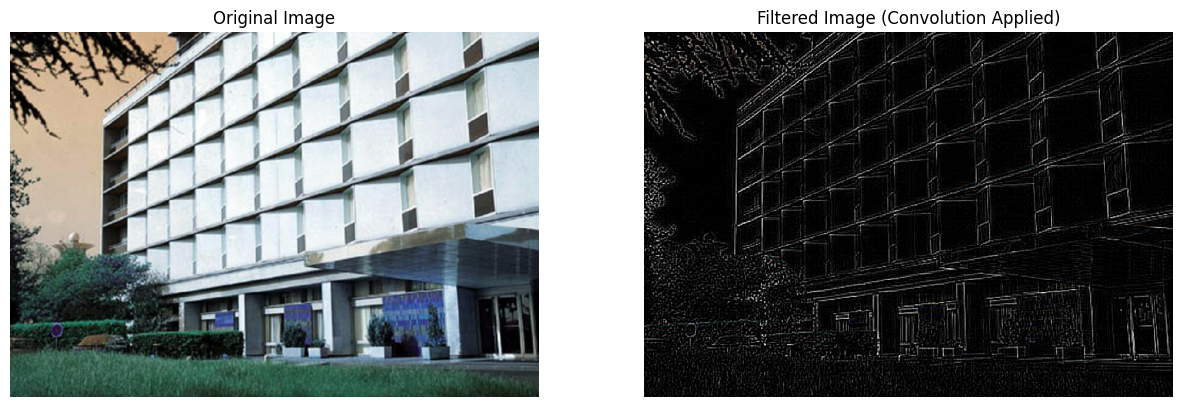

In [12]:
img_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/building.jpg"
image = url_to_image(img_url)

# Try out these kernels!
# Kernel 1: Edge Detection (Finds areas of high contrast)
kernel_edge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Kernel 2: Sharpen (Accentuates details)
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# Kernel 3: Box Blur (Averages the surrounding pixels together)
kernel_blur = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
]) / 5.0

# Kernel 4: Custom (Hack around with this one! Just try to keep the sum near 0 or 1)
custom_kernel = np.array([
    [ 1,  0, -1],
    [ 2,  0, -2],
    [ 1,  0, -1]
])

# Choose which kernel to apply
active_kernel = kernel_edge

# Apply the sliding window filter using OpenCV
# The '-1' just tells OpenCV to keep the output image the same color depth as the input
filtered_image = cv2.filter2D(image, -1, active_kernel)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(15, 8))
axs[0].imshow(image)
axs[0].set_title("Original Image")
axs[0].axis('off')

axs[1].imshow(filtered_image)
axs[1].set_title("Filtered Image (Convolution Applied)")
axs[1].axis('off')

plt.show()

## Part 4: Object Detection with YOLOv8 (You Only Look Once)
Color tracking is great, but it doesn't know *what* an object is.

Enter YOLO. This is the undisputed champion of hackathon computer vision. We are going to download a pre-trained neural network that already knows how to identify 80 different classes of objects instantly.

We feed it an image, and it returns:
1. Bounding Boxes (Where is it?)
2. Class Labels (What is it?)
3. Confidence Scores (How sure am I?)

Running YOLO inference...

Found https://media.wired.com/photos/59a459d3b345f64511c5e3d4/16:9/w_2494,h_1403,c_limit/MemeLoveTriangle_297886754.jpg locally at MemeLoveTriangle_297886754.jpg
image 1/1 /content/MemeLoveTriangle_297886754.jpg: 384x640 6 persons, 101.9ms
Speed: 2.1ms preprocess, 101.9ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


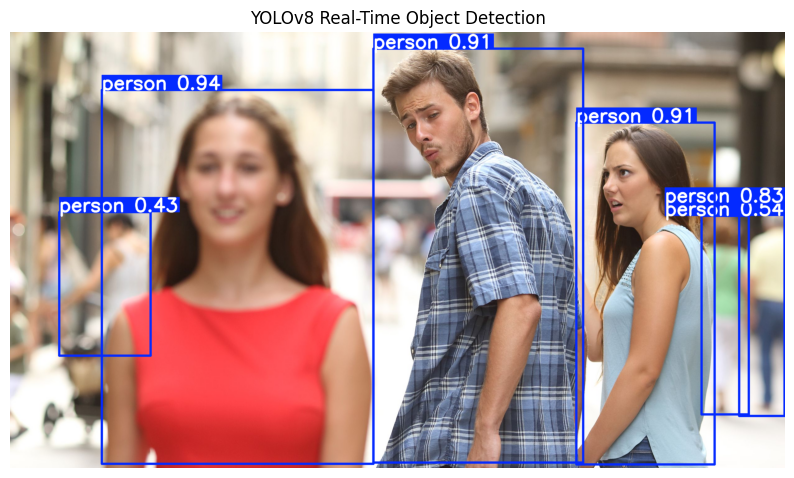

In [13]:
# Load the pre-trained YOLOv8 model
model = YOLO('yolov8n.pt')

# Define an image URL
test_image_url = 'https://media.wired.com/photos/59a459d3b345f64511c5e3d4/16:9/w_2494,h_1403,c_limit/MemeLoveTriangle_297886754.jpg'

# call inference
print("Running YOLO inference...")
results = model(test_image_url)

# Extract the plotted image
annotated_frame = results[0].plot()

annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(10, 8))
plt.imshow(annotated_frame_rgb)
plt.title("YOLOv8 Real-Time Object Detection")
plt.axis('off')
plt.show()

## Part 4: The Math Trick (Monocular Depth Estimation)
YOLO gives us a 2D bounding box, but we live in a 3D world. How do we know how far away that person is?

If you only have one camera (like a standard webcam), you can use **Triangle Similarity**.
If we know roughly how tall an object is in the real world (e.g., an average human is about 165 cm tall), and we know the focal length of our camera, we can use the height of the YOLO bounding box to calculate the exact distance!

The formula is simple:
Distance = (Real Height * Focal Length) / Pixel Height

Let's test it on a trick photography image!


Found https://ftp.nfi.edu/wp-content/uploads/2021/10/Forced-Perspective_img1.png locally at Forced-Perspective_img1.png
image 1/1 /content/Forced-Perspective_img1.png: 640x448 4 persons, 110.8ms
Speed: 7.5ms preprocess, 110.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 448)
Distance Estimations:
Person 1: 2.31 meters away
Person 2: 24.71 meters away
Person 3: 23.32 meters away
Person 4: 24.61 meters away


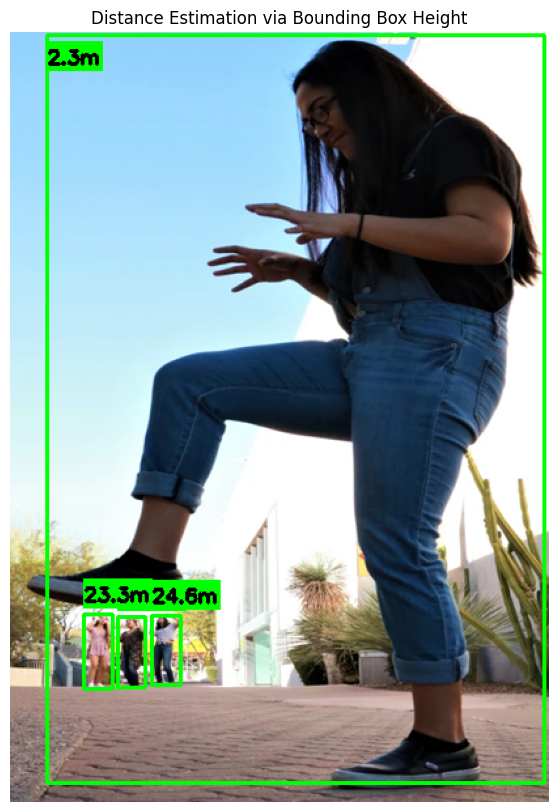

In [14]:
img = url_to_image("https://ftp.nfi.edu/wp-content/uploads/2021/10/Forced-Perspective_img1.png" )

# Define our real-world constants
KNOWN_HEIGHT_CM = 165.0
FOCAL_LENGTH = 800.0

results = model("https://ftp.nfi.edu/wp-content/uploads/2021/10/Forced-Perspective_img1.png" )

# Create a copy of the image to draw on
draw_img = img.copy()

# Loop through every detected object
person_count = 1
print("Distance Estimations:")

for box in results[0].boxes:
    class_id = int(box.cls[0])

    # Note: YOLO defines people as 'class 0' We only want to measure people!
    if class_id == 0:
        # Get the bounding box coordinates
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        # Calculate the height of the bounding box in pixels
        pixel_height = y2 - y1

        # The math
        distance_cm = (KNOWN_HEIGHT_CM * FOCAL_LENGTH) / pixel_height
        distance_meters = distance_cm / 100.0

        print(f"Person {person_count}: {distance_meters:.2f} meters away")
        person_count += 1

        # Draw the bounding box
        cv2.rectangle(draw_img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        label = f"{distance_meters:.1f}m"
        (text_width, text_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        text_y = int(y1) - 10 if int(y1) - 20 > 0 else int(y1) + text_height + 10
        cv2.rectangle(draw_img, (int(x1), text_y - text_height - 5), (int(x1) + text_width, text_y + 5), (0, 255, 0), -1)
        cv2.putText(draw_img, label, (int(x1), text_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

# Convert back to RGB and Plot for Matplotlib
final_img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 10))
plt.imshow(final_img_rgb)
plt.title("Distance Estimation via Bounding Box Height")
plt.axis('off')
plt.show()